# WEC Farm Simulation
In this section we bout to demonstrate how to setup the required objects to run our WEC Farm Simulation.


## Objects and Responsibilities

* ### WaveField (Site) 
    Provides the sea-state distribution over **wave height (H)**, **period (T)**, and **direction (D)**. The site returns either:  
      * **probabilities** `P(H,T,D)` that sum to **1.0** per device (`kind='prob'`)  

      * **hours** `Hours(H,T,D)` that sum to **8760** per device (`kind='hours'`)

<br>

* ### WEC Device 
    Supplies **peak power** on the `(H,T,D)` grid via a surrogate trained on WEC‑Sim: `Power_kW(H,T,D)` (kW). 

    NOTE: A scalar **alpha** maps peak to mean power is being used, it is a temporary feature that must be changed when a new model is implemented:
    `MeanPower_kW(H,T,D) ≈ alpha × Power_kW(H,T,D)`.

<br>

* ### WecFarm (Farm)  
    Binds the site and device to compute **AEP per device** and **total farm AEP**.


### WaveField (`site`) 
The `site` offers a concise description of a location’s wave climate, enhanced by `xrarray`. It provides the probabilities of wave `height (H)`, `period (T)`, and `direction (D)`, and optionally illustrates how these parameters vary across space `(x, y)` for grid spatial distribution analysis. You may select device locations to retrieve the specific combination of `H`, `T`, and `D` that they will experience. From the site, you can access sea state distributions for each device, available as probabilities or hours per year. Furthermore, it features direction roses for the entire area or specific devices, as well as expected maps such as the average wave height `E[H](x, y)` and period `E[T](x, y)`. This resource serves as a crucial backbone for wave climate data, supporting power estimation, layout optimization, and effective visualization.

`Site (XR-backed WaveField)`
* A compact container of a location’s wave climate over H, T, D (and optionally x, y) that you can query and summarize.
  
* Key methods: `local_seastate(x,y)` gets the local H–T–D distribution weight; `direction_distribution(...)` gives a wave-rose; `expected_map('H'|'T')` gives average height/period.

<br>

`UniformWaveField`
* A non-spatial site: one fixed H–T–D probability table applies everywhere.
  
* Methods: constructor from bin edges (optionally with `pdf`), `from_constant(H,T,D)`, and `from_scatter_and_rose(H_edges,T_edges,D_edges,P_HT,P_D)`.

<br>

`RandomGridWaveField`
* A spatial site: a full probability cube $P(H,T,D,x,y)$ at each grid cell, with optional smoothing for realism.
  
* Methods: constructor from edges and grid (optionally with `grid_P`), and `from_scatter_and_rose_maps(...)` to build per-cell climatology.
  
<br>
<b>Note:</b> <span style="color: yellow;">a loader class will be added to read real sea-state files and produce sites in the exact format used by these simulations.</span>

### Usage Example

Begin with setting up site, here we defining three different sites for three different cases.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from waveField import UniformWaveField, RandomGridWaveField


# Define bin edges (H in m, T in s, D in deg)
H_edges = np.linspace(0.5, 4.0, 7)   # 6 H bins
T_edges = np.linspace(5.0, 10.0, 6)  # 5 T bins
D_edges = np.linspace(0.0, 360.0, 13)  # 12 D bins (full compass)

# 1) UniformWaveField WITHOUT pdf (your class handles the edge case)
site_no_pdf = UniformWaveField(H_edges, T_edges, D_edges)

# 2) UniformWaveField WITH pdf
rng = np.random.default_rng(0)
pdf = rng.random((len(H_edges)-1, len(T_edges)-1, len(D_edges)-1))
site_pdf = UniformWaveField(H_edges, T_edges, D_edges, pdf=pdf)

# 3) RandomGridWaveField WITHOUT grid_P (random field, your class normalizes per cell)
xg = np.linspace(0, 1000, 30)
yg = np.linspace(0, 1000, 30)
site_grid = RandomGridWaveField(H_edges, T_edges, D_edges, xg, yg, smooth_sigma=0.5)

Therefore, we will compute the wave condition of the local sea states for the different sites and visualize their probability distribution for H, T, and D.

Uniform (no pdf)
  sum P(H), P(T), P(D): 0.9999999999999998 1.0 1.0


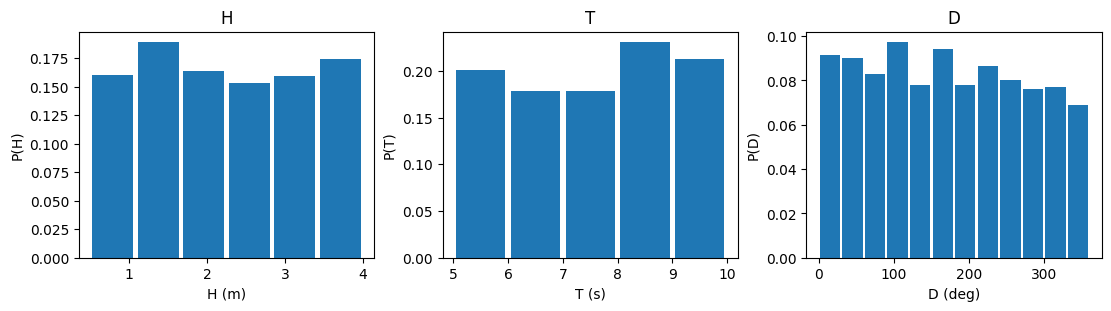

Uniform (with pdf)
  sum P(H), P(T), P(D): 1.0 1.0000000000000002 1.0


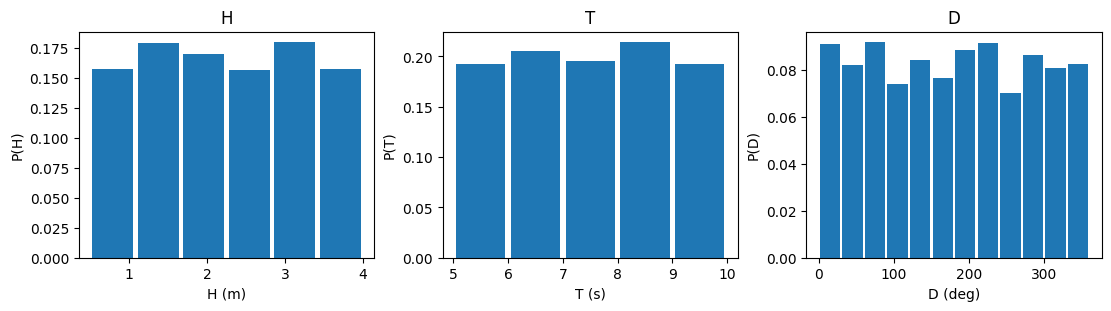

Grid (random, smoothed)
  sum P(H), P(T), P(D): 0.9999999999999999 1.0 0.9999999999999998


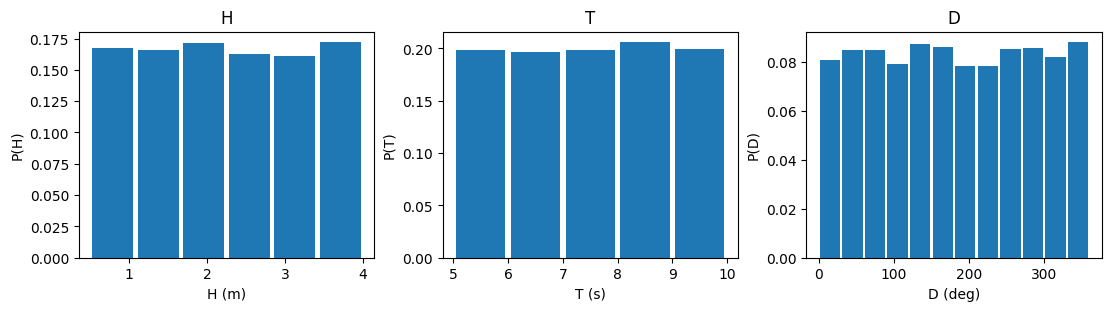

In [35]:
# For uniform sites, x,y are ignored; for the grid site, pick a point in the grid.
x0, y0 = 500.0, 500.0

# Use stored centers from any Uniform site (same centers across sites with same edges)
Hc = site_no_pdf.ds['H'].values
Tc = site_no_pdf.ds['T'].values
Dc = site_no_pdf.ds['D'].values

sites = [
    ("Uniform (no pdf)", site_no_pdf, 0.0, 0.0),
    ("Uniform (with pdf)", site_pdf, 0.0, 0.0),
    ("Grid (random, smoothed)", site_grid, x0, y0),
]

for name, site, xs, ys in sites:
    P = site.local_seastate([xs], [ys], kind="prob")   # dims: H,T,D,wec
    PH = P.sum(dim=('T','D','wec')).values
    PT = P.sum(dim=('H','D','wec')).values
    PD = P.sum(dim=('H','T','wec')).values

    print(name)
    print("  sum P(H), P(T), P(D):",
          np.sum(PH), np.sum(PT), np.sum(PD))

    fig, ax = plt.subplots(1, 3, figsize=(11, 3), constrained_layout=True)
    ax[0].bar(Hc, PH, width=(Hc[1]-Hc[0])*0.9)
    ax[0].set_xlabel("H (m)"); ax[0].set_ylabel("P(H)"); ax[0].set_title("H")

    ax[1].bar(Tc, PT, width=(Tc[1]-Tc[0])*0.9)
    ax[1].set_xlabel("T (s)"); ax[1].set_ylabel("P(T)"); ax[1].set_title("T")

    ax[2].bar(Dc, PD, width=(Dc[1]-Dc[0])*0.9)
    ax[2].set_xlabel("D (deg)"); ax[2].set_ylabel("P(D)"); ax[2].set_title("D")
    plt.show()

---

### WEC Device


Wec Device is currently very basic. Essentialy like previously mentioned they provide peak power produce by a wec device when placed in the waveField. Thus, we currently have a one device which was developed using a surrogate model trained on data and result simulations from WecSim on the [OSWEC device](https://wec-sim.github.io/WEC-Sim/dev/user/tutorials.html#oscillating-surge-wec-oswec).

`OSWECDevice()`

A lightweight surrogate model that predicts wave energy converter peak power (kW) from a sea state `(H,T,D)`. You use it to quickly get power at a single state or across a grid of states, can be used to map power over your waveField bins.

**Note:** Currently the model is predicting using a `alpha` parameter with intent to compute mean power from peak power in which will be used for the WecFarm simulation. <span style="color: yellow;">Later the goal is to train the model on wecsim to already provide meanpower so we have a more accurate evaluations. Also the model is currently trained only on `regular wave` scenarios. Also later we plan to dev a abstract class device, in which all the Wec Devices model being trained will be wrapped around it.</span>

### Usage Example

In [36]:
import numpy as np
from wec_device import OSWECDevice

# 1) Instantiate model
dev = OSWECDevice()

# 2) Single sea state power (kW)
p = dev.power_point(H=5.0, T=3.0, D=15.0)
print("Power @ (H=6.0 m, T=3.0 s, D=15°):", p, "kW")

# 3) Grid power over H,T,D bin centers
Hc = np.linspace(0.5, 4, 6)
Tc = np.linspace(5.5, 9.5, 5)
Dc = np.linspace(5.0, 90.0, 6)

Pgrid = dev.power_grid(Hc, Tc, Dc)   


print("Grid shape:", Pgrid.shape)
print("Grid power (kW):\n", Pgrid[:5, :5, :5])  # print the first 5x5x5 block

Power @ (H=6.0 m, T=3.0 s, D=15°): 10.413322 kW
Grid shape: (6, 5, 6)
Grid power (kW):
 [[[ 0.3002348   0.328347    0.157304    0.18888883  0.10836994]
  [ 0.3549306   0.47015563  0.30072773  0.19404195  0.11795098]
  [ 0.49121517  0.50226927  0.3558902   0.20438181  0.13899098]
  [ 0.6176362   0.5555188   0.34985983  0.21371974  0.14159685]
  [ 0.69389606  0.60380954  0.44373593  0.3425949   0.21776128]]

 [[ 1.3260615   1.0805453   0.72489953  0.36688346  0.20938112]
  [ 1.363631    1.3505694   0.87436044  0.45660242  0.22135006]
  [ 1.8944116   1.6192766   1.0470581   0.5864223   0.26727974]
  [ 2.2775774   1.9864161   1.2374667   0.7374604   0.28564176]
  [ 2.631867    2.4265366   1.5504771   0.9218329   0.27424026]]

 [[ 3.0383449   2.4890141   1.7002312   0.7070687   0.28938955]
  [ 3.7984798   3.2756703   2.2181702   0.9881416   0.32865065]
  [ 4.6813006   3.8240454   2.623252    1.398213    0.49531567]
  [ 5.870166    4.8020186   3.1452682   1.781194    0.55531025]
  [ 7.221343

---

### WEC Farm Simulation (WecFarm)


**WecFarm** integrates a wave site with a WEC device to turn sea-state statistics into energy. For each device coordinate $(x,y)$, it retrieves either probabilities $P(H,T,D|x,y)$ or **annual hours per sea-state bin at that location**, multiplies these by the device power surface $P_{\text{kW}}(H,T,D)$, applies the scale factor α\alphaα, and sums over bins to get per-device AEP (GWh/yr) and the farm total. It also exposes the device power grid on the site bins, the per-device annual hours per bin, and the expected device power under the site distribution.

**Note:** <span style="color: yellow;">Need to validate the computation of energy method, and the process to be used. Might need an update later</span>

### Usage Example

In [37]:
# We going use the previous site_no_pdf, site_pdf and site_grid from waveField.py
# and the device model dev from wec_device.py
from wecFarm import WecFarm

H_edges = np.linspace(0.5, 4.0, 8)
T_edges = np.linspace(5.0, 10.0, 11)
D_edges = np.linspace(0.0, 90.0, 10)

x_dev = [120.0, 555.0, 880.0]
y_dev = [100.0, 420.0, 600.0]


farm_no_pdf = WecFarm(site_no_pdf, x_dev, y_dev, dev)

farm_pdf = WecFarm(site_pdf, x_dev, y_dev, dev)

farm_grid = WecFarm(site_grid, x_dev, y_dev, dev)


In [38]:

# Result for the uniform site without pdf
print("Uniform(no pdf) — Expected device power [kW]:", farm_no_pdf.expected_peak_power_kW())
print("Uniform(no pdf) — Per-device AEP [GWh]:", farm_no_pdf.aep().values)
print("Uniform(no pdf) — Farm AEP [GWh]:", farm_no_pdf.aep_farm())

# Result for the uniform site with pdf
print("------------------------------------------------")
print("Uniform(with pdf) — Expected device power [kW]:", farm_pdf.expected_peak_power_kW())
print("Uniform(with pdf) — Per-device AEP [GWh]:", farm_pdf.aep().values)
print("Uniform(with pdf) — Farm AEP [GWh]:", farm_pdf.aep_farm())

# Result for the grid site
print("------------------------------------------------")
print("Grid — Expected device power [kW]:", farm_grid.expected_peak_power_kW())
print("Grid — Per-device AEP [GWh]:", farm_grid.aep().values)
print("Grid — Farm AEP [GWh]:", farm_grid.aep_farm())

Uniform(no pdf) — Expected device power [kW]: [1.1453499 1.1453499 1.1453499]
Uniform(no pdf) — Per-device AEP [GWh]: [0.58192937 0.58192937 0.58192937]
Uniform(no pdf) — Farm AEP [GWh]: 1.7457881080788884
------------------------------------------------
Uniform(with pdf) — Expected device power [kW]: [1.22466312 1.22466312 1.22466312]
Uniform(with pdf) — Per-device AEP [GWh]: [0.62222683 0.62222683 0.62222683]
Uniform(with pdf) — Farm AEP [GWh]: 1.8666804949253262
------------------------------------------------
Grid — Expected device power [kW]: [1.12698974 1.06061785 1.11138954]
Grid — Per-device AEP [GWh]: [0.57260094 0.53887871 0.56467479]
Grid — Farm AEP [GWh]: 1.6761544445762149


In case we want to plot the spatial view for the site_grid:

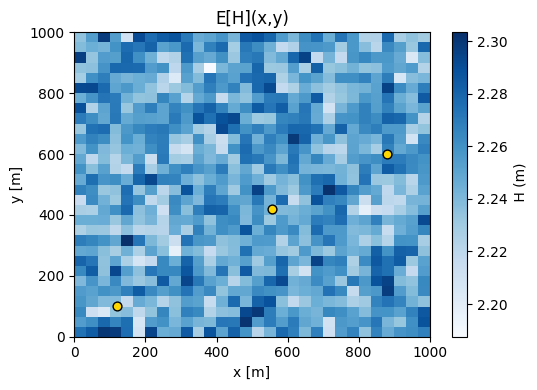

In [30]:
# In case we want to plot the spatial view for the site_grid:
EH = site_grid.expected_map('H')
plt.figure(figsize=(5.5,4))
im = plt.imshow(EH.T, origin='lower', cmap='Blues',
                extent=(xg.min(), xg.max(), yg.min(), yg.max()),
                aspect='auto')
plt.scatter(x_dev, y_dev, c='gold', s=40, edgecolor='k')
plt.xlabel('x [m]'); plt.ylabel('y [m]'); plt.title('E[H](x,y)')
plt.colorbar(im, label=' H (m)')
plt.tight_layout()
plt.show()

---

### Optimization Usage Example (`optimize_wec_loc.py`)

For this Optimization usage, we setup all the ExplicitComponents needed for the Wec optimization in the file `optimize_wec_loc.py`. Plus we have a function there called `wec_problem()`, in which you just need to pass the parameters and it will run a wec optimization problem for you.

**Note:** Currently the function `wec_problem()` only considers spacing constraint between our devices. Plus, it is running with the `SLSQP` driver. Further changes waas done into the `optimization_WF_WeC.py` where more Components were added including the boundary constraints. Another limitation is the way finite differences is computed, and it only accepts finite differenece as the method. <span style="color: yellow;">For Future work implement other optimization methods, such as gradients!!</span>

In [33]:
from optimize_wec_loc import wec_problem

# Example usage of the wec_problem function
# ---- 1) Site (spatial) ----
H_edges = np.linspace(0.5, 4.0, 20)
T_edges = np.linspace(5.0, 10.0, 20)
D_edges = np.linspace(0.0, 90.0, 13)

xg = np.linspace(0, 1200, 10)
yg = np.linspace(0, 1200, 10)

# Example: build random spatial climate
site = RandomGridWaveField(H_edges, T_edges, D_edges, xg, yg, smooth_sigma=0.5)

# ---- 2) Device (auto-loads surrogate & scalers)
device = OSWECDevice()  # pick your alpha; 5.0 ~ 2.6-2.8 GWh per device in your tests

# ---- 3) Initial layout (grid-ish)
x_init = np.array([100, 300, 500, 700, 900,   150, 350, 550, 750, 950,   250, 450], dtype=float)
y_init = np.array([150, 150, 150, 150, 150,   400, 400, 400, 400, 400,   650, 650], dtype=float)
nd = len(x_init)


# ---- 4) Build & run optimization ----
D_min = 150.0  # meters
prob = wec_problem(site, device, x_init, y_init, D_min)

# Get bin centers for plotting/maps
Hc = site.ds['H'].values
Tc = site.ds['T'].values
Dc = site.ds['D'].values

# Initial evaluation
prob.run_model()
AEP_init = prob.get_val("AEP_total").item()

# Optimize
prob.run_driver()

x_opt = prob.get_val("x").astype(float)
y_opt = prob.get_val("y").astype(float)
AEP_opt = prob.get_val("AEP_total").item()

gain_pct = 100.0 * (AEP_opt - AEP_init) / max(1e-9, abs(AEP_init))
print("\n=== Farm AEP Optimization ===")
print(f"Devices: {len(x_init)},  Spacing min = {D_min:.1f} m")
print(f"AEP total [GWh]: init={AEP_init:.3f}   opt={AEP_opt:.3f}   gain={gain_pct:.2f}%")

Optimization terminated successfully    (Exit mode 0)
            Current function value: -26.087312615421443
            Iterations: 9
            Function evaluations: 16
            Gradient evaluations: 9
Optimization Complete
-----------------------------------

=== Farm AEP Optimization ===
Devices: 12,  Spacing min = 150.0 m
AEP total [GWh]: init=25.874   opt=26.087   gain=0.82%
